In [88]:
import numpy as np
import shap
shap.initjs()
import sklearn
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [89]:
#pip install ucimlrepo

In [90]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features.copy()
y = adult.data.targets.copy().iloc[:, 0]
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [91]:
## Preprocessing steps ##

# Missing numbers
X = X.replace("?", pd.NA)

y = y.astype(str).str.strip()


valid_target = y.isin(["<=50K", ">50K", "<=50K.", ">50K."])
X = X.loc[valid_target]
y = y.loc[valid_target]

valid_X = X.notna().all(axis=1)
X = X.loc[valid_X]
y = y.loc[valid_X]


# Convert target to binary
y = y.map({
    "<=50K": 0,
    ">50K": 1,
    "<=50K.": 0,
    ">50K.": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaNs in y:", y.isna().sum())
print("Class distribution:")
print(y.value_counts())

# Separate categorical and numerical features
categorical_cols = X.select_dtypes(include=["object", "string"]).columns
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X shape: (45222, 14)
y shape: (45222,)
NaNs in y: 0
Class distribution:
income
0    34014
1    11208
Name: count, dtype: int64


In [92]:
## Train/test split ##
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain/test shapes:")
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


Train/test shapes:
(36177, 96) (9045, 96)
income
0    27211
1     8966
Name: count, dtype: int64
income
0    6803
1    2242
Name: count, dtype: int64


In [93]:
## Feature scaling (mainly for nn) ##
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [94]:
# Convert features to numeric for XGBoost
X_train_num = X_train.astype("float32")
X_test_num = X_test.astype("float32")

y_train_num = y_train.astype("int")
y_test_num = y_test.astype("int")

## XGBOOST

In [95]:
from xgboost import XGBClassifier

In [96]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_num, y_train_num)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [97]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = xgb_model.predict(X_test_num)
y_proba = xgb_model.predict_proba(X_test_num)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8671088999447208
ROC AUC: 0.925600298603636

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.91      6803
           1       0.79      0.63      0.70      2242

    accuracy                           0.87      9045
   macro avg       0.84      0.79      0.81      9045
weighted avg       0.86      0.87      0.86      9045


Confusion Matrix:
 [[6429  374]
 [ 828 1414]]


In [98]:
print("Unique predicted probabilities:")
print(pd.Series(y_proba).round(6).value_counts().head(10))

print("Min prob:", y_proba.min())
print("Max prob:", y_proba.max())
print("Mean prob:", y_proba.mean())

Unique predicted probabilities:
0.198429    6
0.000973    4
0.001569    4
0.000636    4
0.000825    4
0.002205    4
0.000863    4
0.001020    4
0.000620    3
0.000804    3
Name: count, dtype: int64
Min prob: 0.00025465438
Max prob: 0.9981864
Mean prob: 0.24355717


In [99]:
#SAVING RESULTS
xgb_results = {
    "accuracy": accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

print(xgb_results)

{'accuracy': 0.8671088999447208, 'roc_auc': 0.925600298603636}


                              feature  importance
28  marital-status_Married-civ-spouse    0.341843
30       marital-status_Never-married    0.087735
3                        capital-gain    0.048390
2                       education-num    0.044389
21                education_Doctorate    0.031067
39           occupation_Other-service    0.023328
35         occupation_Exec-managerial    0.021991
23                  education_Masters    0.019836
20                education_Bachelors    0.019237
41          occupation_Prof-specialty    0.017840
4                        capital-loss    0.017614
25              education_Prof-school    0.016440
46         relationship_Not-in-family    0.015372
48             relationship_Own-child    0.014362
36         occupation_Farming-fishing    0.013502


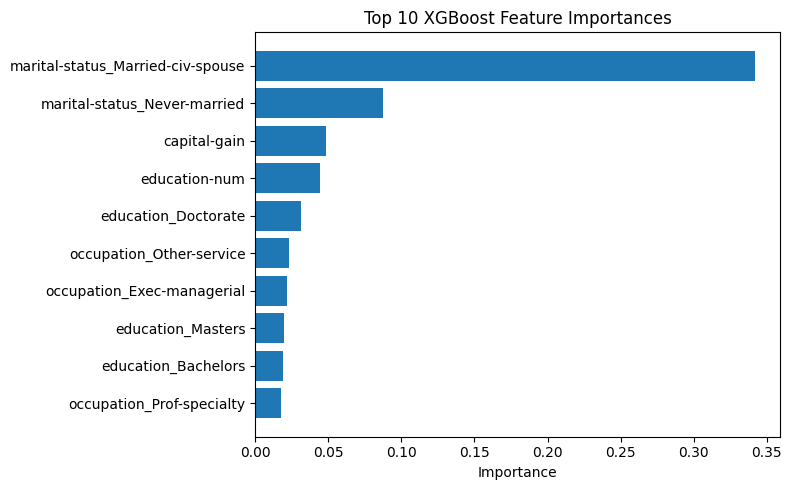

In [100]:
feature_importance = pd.DataFrame({
    "feature": X_train_num.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(15))

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# SHAP on XGBOOST

In [101]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_num)

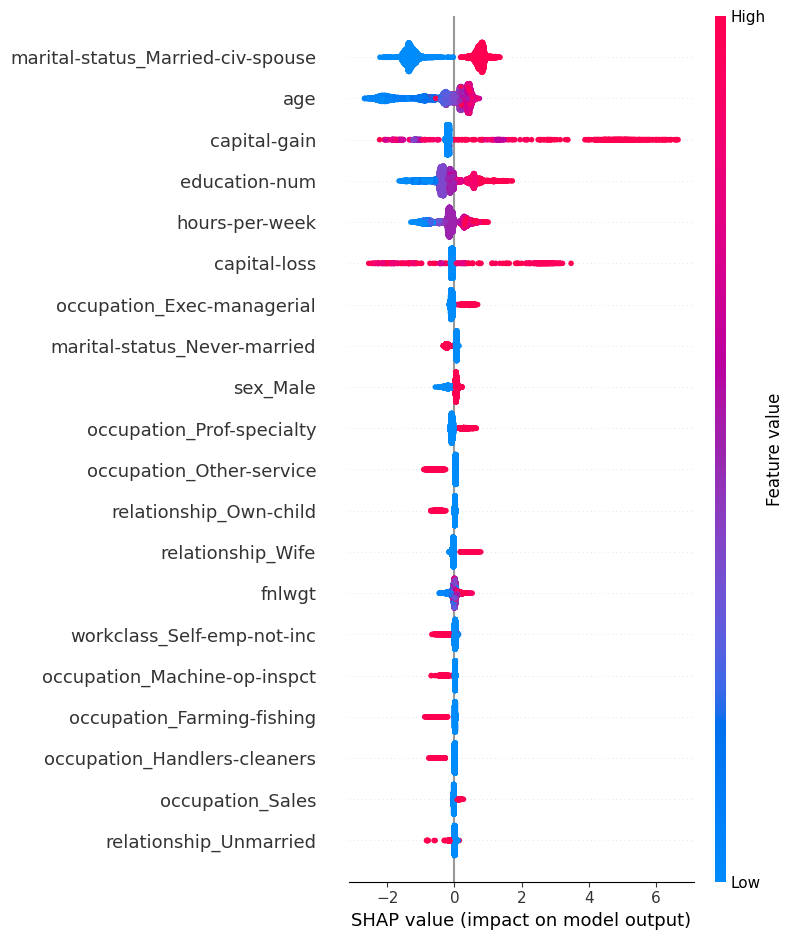

In [102]:
shap.summary_plot(shap_values, X_test_num)

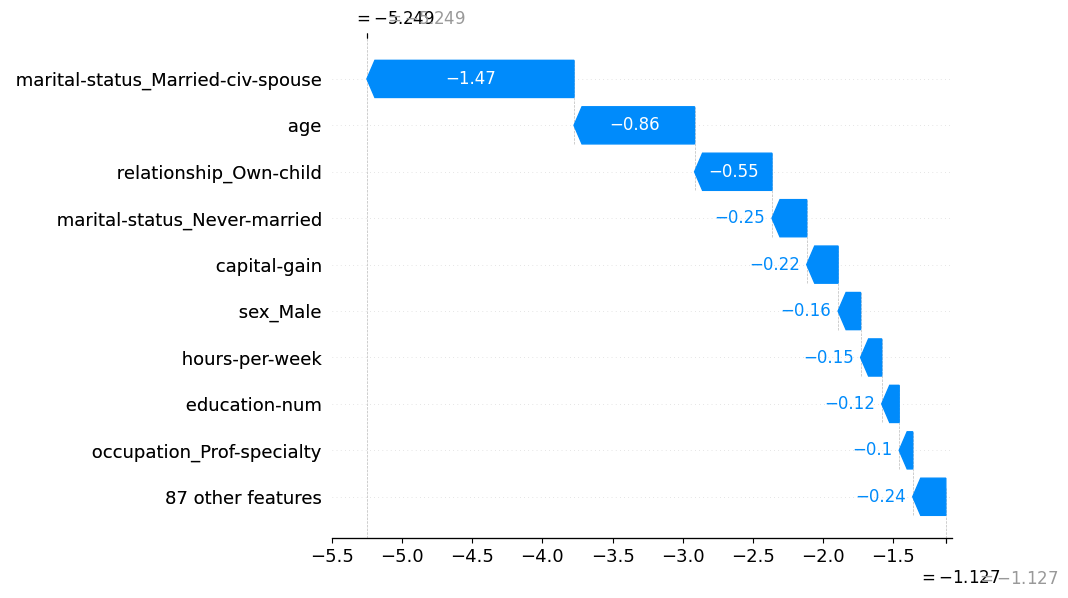

In [103]:
# For individuel person
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    X_test_num.iloc[0]
)

## LIME for individuel XGBOOST

LIME explanation as list:
[('capital-gain <= 0.00', -0.7443279117353314), ('marital-status_Married-civ-spouse <= 0.00', -0.11524729254693585), ('native-country_Canada <= 0.00', -0.09710218806282511), ('age <= 28.00', -0.09369460128009491), ('hours-per-week <= 40.00', -0.08121798901943633), ('native-country_Poland <= 0.00', 0.07138547430480571), ('native-country_Ireland <= 0.00', -0.05593115144434963), ('native-country_Hong <= 0.00', 0.05520143998674338), ('native-country_Iran <= 0.00', -0.05281590035768217), ('native-country_Outlying-US(Guam-USVI-etc) <= 0.00', -0.034085936945450125)]


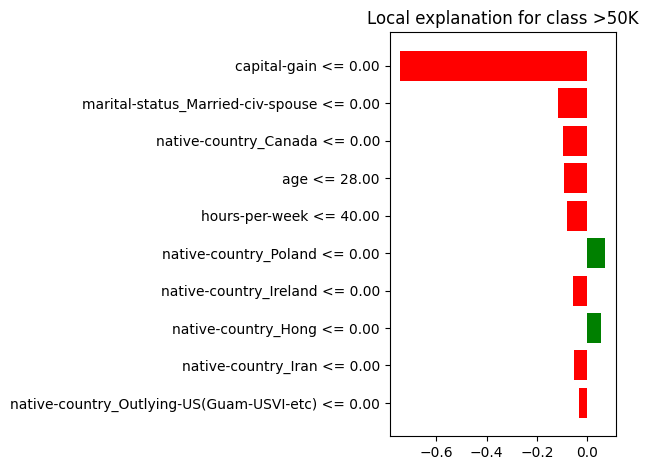

In [107]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_num),
    feature_names=X_train_num.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

exp = lime_explainer.explain_instance(
    data_row=X_test_num.iloc[0].values,
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

print("LIME explanation as list:")
print(exp.as_list())

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

# Neural Network

In [108]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Build neural network
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

# Compile
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Predict
y_proba_nn = nn_model.predict(X_test_scaled).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

# Evaluate
print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))
print("NN ROC AUC:", roc_auc_score(y_test, y_proba_nn))
print("\nNN Classification Report:\n", classification_report(y_test, y_pred_nn))
print("\nNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

Epoch 1/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8195 - loss: 0.3960 - val_accuracy: 0.8371 - val_loss: 0.3444
Epoch 2/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8414 - loss: 0.3432 - val_accuracy: 0.8409 - val_loss: 0.3358
Epoch 3/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8482 - loss: 0.3300 - val_accuracy: 0.8431 - val_loss: 0.3327
Epoch 4/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8511 - loss: 0.3248 - val_accuracy: 0.8444 - val_loss: 0.3282
Epoch 5/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8533 - loss: 0.3205 - val_accuracy: 0.8434 - val_loss: 0.3293
Epoch 6/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8538 - loss: 0.3183 - val_accuracy: 0.8481 - val_loss: 0.3274
Epoch 7/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8560 - loss: 0.3156 - val_accuracy: 0.8434 - val_loss: 0.3271
Epoch 8/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8544 - loss: 0.3144 - val_accuracy: 0.

# SHAP on NN

100%|██████████| 50/50 [00:19<00:00,  2.58it/s]


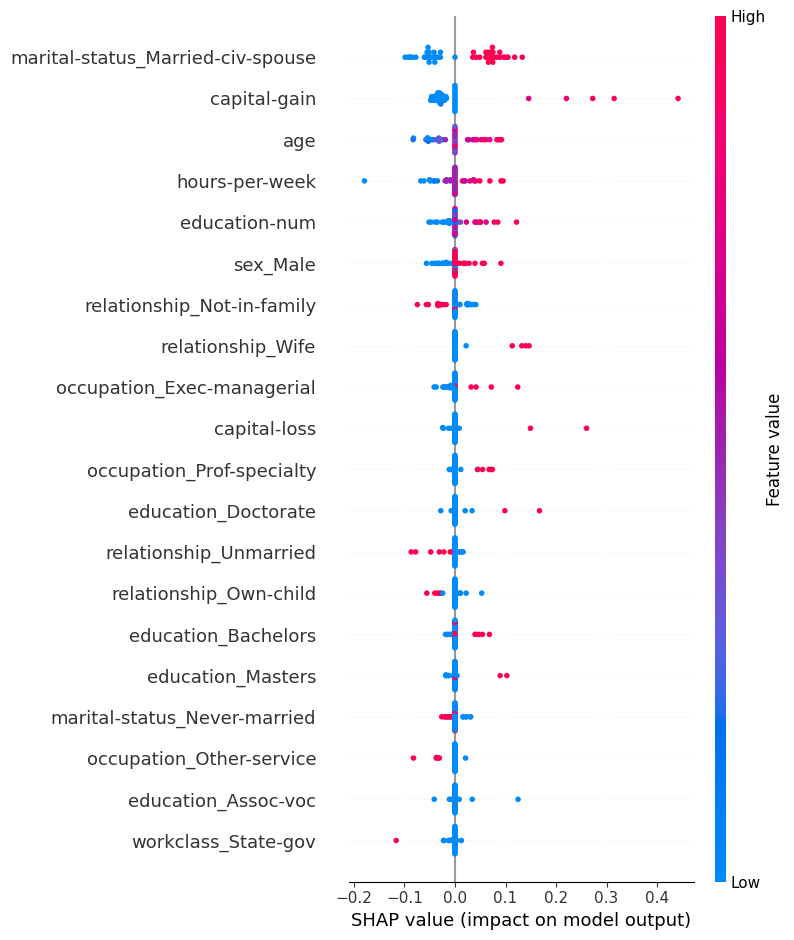

In [ ]:
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)] # Background sample for SHAP
X_test_sample = X_test_scaled[:50] # Test sample to explain

# Wrapper so SHAP gets a 1D output
def nn_predict(x):
    return nn_model.predict(x, verbose=0).ravel()

explainer = shap.KernelExplainer(nn_predict, background)

shap_values = explainer.shap_values(X_test_sample, nsamples=100)

shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X_train.columns
)

In [115]:
instance = X_test_sample[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[10],
    instance,
    feature_names=X_train.columns
)

## LIME on NN

[('capital-gain <= -0.15', -0.6150462224214441), ('native-country_Ecuador <= -0.03', 0.32839704158254696), ('education_Preschool <= -0.04', 0.25309639712825455), ('native-country_South <= -0.05', 0.24689194846301118), ('native-country_Columbia <= -0.04', 0.18905574111986365), ('native-country_Scotland <= -0.02', 0.1640753969445243), ('native-country_Outlying-US(Guam-USVI-etc) <= -0.02', 0.16347596156156632), ('native-country_Thailand <= -0.02', 0.12214931296878936), ('native-country_Peru <= -0.03', 0.0948337275029797), ('marital-status_Married-AF-spouse <= -0.03', -0.0903499618914921)]


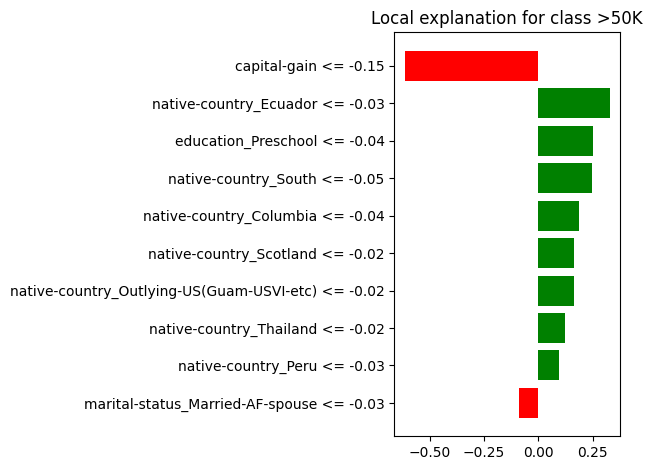

In [116]:
from lime.lime_tabular import LimeTabularExplainer

# NN predict_proba wrapper for LIME
def nn_predict_proba(x):
    p1 = nn_model.predict(x, verbose=0).ravel()
    p0 = 1 - p1
    return np.column_stack((p0, p1))

# LIME explainer
lime_explainer_nn = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X_train.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

# Explain one individual
idx = 0
exp_nn = lime_explainer_nn.explain_instance(
    data_row=X_test_scaled[idx],
    predict_fn=nn_predict_proba,
    num_features=10
)

print(exp_nn.as_list())

fig = exp_nn.as_pyplot_figure()
plt.tight_layout()
plt.show()